<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-XLA/blob/main/BVU_CaoHoc_BuiVanHuan_BT_ThaoLuan_Nhom1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np

In [10]:
# Ma trận gốc
A = np.array([[0,1,2,3],
              [1,2,3,4],
              [2,3,4,5],
              [3,4,5,7]])

# --- Câu 1: Âm bản ---
A_N = 7 - A
print("Ma trận âm bản:\n", A_N)


Ma trận âm bản:
 [[7 6 5 4]
 [6 5 4 3]
 [5 4 3 2]
 [4 3 2 0]]


In [12]:

# Ma trận gốc
A = np.array([[0,1,2,3],
              [1,2,3,4],
              [2,3,4,5],
              [3,4,5,7]])

# --- Câu 2: Histogram ---
hist, bins = np.histogram(A, bins=range(9))  # từ 0 đến 7
print("Histogram:", hist)


Histogram: [1 2 3 4 3 2 0 1]


In [13]:
# --- Câu 3: Phân ngưỡng ---
T = 4
A_T = np.where(A < T, 0, 7)
print("Ma trận phân ngưỡng:\n", A_T)

# Đếm số pixel vùng tối/sáng
dark_pixels = np.sum(A_T == 0)
bright_pixels = np.sum(A_T == 7)
print("Số pixel vùng tối:", dark_pixels)
print("Số pixel vùng sáng:", bright_pixels)

Ma trận phân ngưỡng:
 [[0 0 0 0]
 [0 0 0 7]
 [0 0 7 7]
 [0 7 7 7]]
Số pixel vùng tối: 10
Số pixel vùng sáng: 6


In [11]:

# --- Câu 4: Quay ảnh 90° ---
A_R = np.rot90(A, k=-1)  # quay 90 độ theo chiều kim đồng hồ
print("Ma trận quay 90°:\n", A_R)

Ma trận quay 90°:
 [[3 2 1 0]
 [4 3 2 1]
 [5 4 3 2]
 [7 5 4 3]]


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

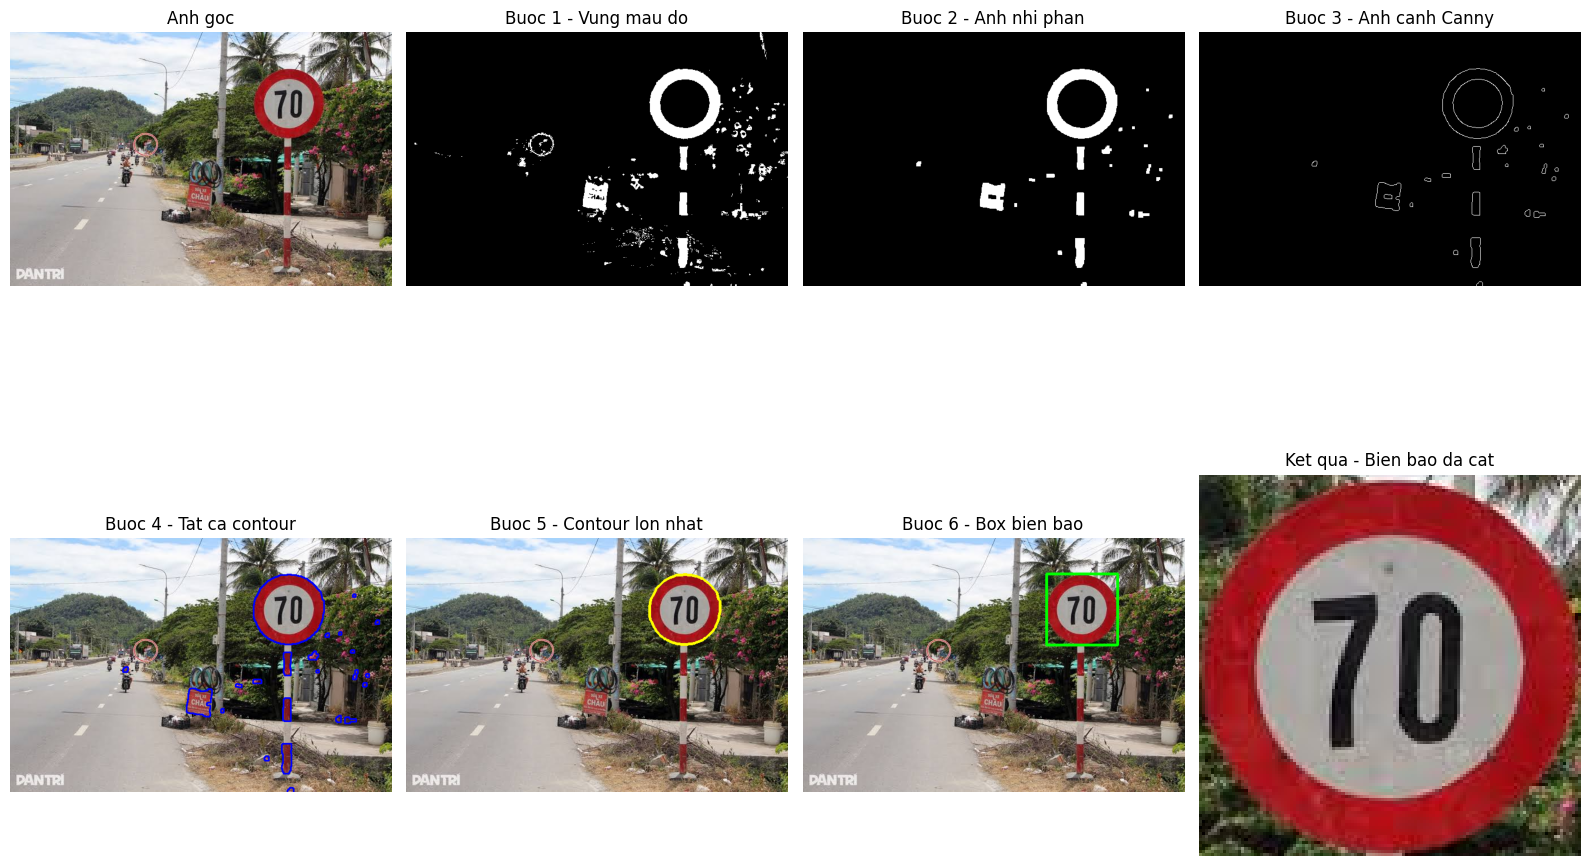

In [26]:
# =========================
# Đọc ảnh đầu vào từ đường dẫn
# =========================
image_path = "/content/drive/My Drive/Colab Notebooks/xla_tl_n1_data_img/1.png"
#image_path = "/content/drive/My Drive/Colab Notebooks/xla_tl_n1_data_img/2.png"
#image_path = "/content/drive/My Drive/Colab Notebooks/xla_tl_n1_data_img/3.png"
#image_path = "/content/drive/My Drive/Colab Notebooks/xla_tl_n1_data_img/4.png"
#image_path = "/content/drive/My Drive/Colab Notebooks/xla_tl_n1_data_img/5.png"
#image_path = "/content/drive/My Drive/Colab Notebooks/xla_tl_n1_data_img/6.png"
#image_path = "/content/drive/My Drive/Colab Notebooks/xla_tl_n1_data_img/7.png"
#image_path = "/content/drive/My Drive/Colab Notebooks/xla_tl_n1_data_img/error.jpg"

image = cv2.imread(image_path)

# =========================
# Bước 1: Chuyển ảnh sang HSV và chọn vùng màu đỏ
# =========================
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_red_1 = np.array([0, 70, 50])
upper_red_1 = np.array([10, 255, 255])
lower_red_2 = np.array([170, 70, 50])
upper_red_2 = np.array([180, 255, 255])

mask_red_1 = cv2.inRange(hsv_image, lower_red_1, upper_red_1)
mask_red_2 = cv2.inRange(hsv_image, lower_red_2, upper_red_2)
red_mask = mask_red_1 + mask_red_2

# =========================
# Bước 2: Vùng đỏ thành trắng, vùng khác thành đen
# =========================
kernel = np.ones((5, 5), np.uint8)
binary_image = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel)
binary_image = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)

# =========================
# Bước 3: Tìm cạnh cho hình
# =========================
edge_image = cv2.Canny(binary_image, 50, 150)

# =========================
# Bước 4: Tìm contour cho hình
# =========================
contours, _ = cv2.findContours(edge_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_image = image.copy()
cv2.drawContours(contour_image, contours, -1, (255, 0, 0), 2)

# =========================
# Bước 5: Xác định contour lớn nhất là biển báo
# =========================
largest_contour = max(contours, key=cv2.contourArea)
largest_contour_image = image.copy()
cv2.drawContours(largest_contour_image, [largest_contour], -1, (0, 255, 255), 3)

# =========================
# Bước 6: Vẽ hình vuông box quanh biển báo và cắt ảnh
# =========================
x, y, w, h = cv2.boundingRect(largest_contour)
box_size = max(w, h)

center_x = x + w // 2
center_y = y + h // 2

square_x1 = max(0, center_x - box_size // 2)
square_y1 = max(0, center_y - box_size // 2)
square_x2 = min(image.shape[1], square_x1 + box_size)
square_y2 = min(image.shape[0], square_y1 + box_size)

cropped_sign = image[square_y1:square_y2, square_x1:square_x2]

result_image = image.copy()
cv2.rectangle(result_image, (square_x1, square_y1), (square_x2, square_y2), (0, 255, 0), 3)

# =========================
# Hiển thị tất cả ảnh bằng matplotlib
# =========================
images = {
    "Anh goc": cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    "Buoc 1 - Vung mau do": red_mask,
    "Buoc 2 - Anh nhi phan": binary_image,
    "Buoc 3 - Anh canh Canny": edge_image,
    "Buoc 4 - Tat ca contour": cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB),
    "Buoc 5 - Contour lon nhat": cv2.cvtColor(largest_contour_image, cv2.COLOR_BGR2RGB),
    "Buoc 6 - Box bien bao": cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB),
    "Ket qua - Bien bao da cat": cv2.cvtColor(cropped_sign, cv2.COLOR_BGR2RGB)
}

plt.figure(figsize=(16, 12))

for i, (name, img) in enumerate(images.items()):
    plt.subplot(2, 4, i+1)   # 2 hàng, 4 cột
    if len(img.shape) == 2:  # ảnh grayscale
        plt.imshow(img, cmap='gray')
    else:                    # ảnh màu
        plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()
